#Setup & Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import random
from collections import deque, Counter
import pandas as pd # Using pandas for a cleaner table display

print("Libraries imported successfully!")

Libraries imported successfully!


#Game Environment Definition

In [ ]:
# We define the core rules of the Iterated Prisoner's Dilemma (IPD)
# based on your "Game-theory background" and "RL modeling" sections.

# --- Actions ---
ACTION_COOPERATE = 0
ACTION_DEFECT = 1
ACTIONS = [ACTION_COOPERATE, ACTION_DEFECT]

# --- States ---
# As defined in your plan (Section 3.1)
STATE_START = 0  # Special start state
STATE_CC = 1     # Both cooperated
STATE_CD = 2     # P1 cooperated, P2 defected
STATE_DC = 3     # P1 defected, P2 cooperated
STATE_DD = 4     # Both defected
STATES = [STATE_START, STATE_CC, STATE_CD, STATE_DC, STATE_DD]

# --- Payoff Matrix ---
PAYOFF_MATRIX = {
    (ACTION_COOPERATE, ACTION_COOPERATE): (3, 3),
    (ACTION_COOPERATE, ACTION_DEFECT):    (0, 5),
    (ACTION_DEFECT,    ACTION_COOPERATE): (5, 0),
    (ACTION_DEFECT,    ACTION_DEFECT):    (1, 1)
}

# --- Environment Functions ---

def get_rewards(action1, action2):
    """Returns the rewards for (P1, P2) based on their joint action."""
    return PAYOFF_MATRIX[(action1, action2)]

def get_next_state(action1, action2):
    """Returns the next state based on the joint action."""
    if (action1, action2) == (ACTION_COOPERATE, ACTION_COOPERATE):
        return STATE_CC
    elif (action1, action2) == (ACTION_COOPERATE, ACTION_DEFECT):
        return STATE_CD
    elif (action1, action2) == (ACTION_DEFECT, ACTION_COOPERATE):
        return STATE_DC
    elif (action1, action2) == (ACTION_DEFECT, ACTION_DEFECT):
        return STATE_DD
    else:
        # This should not happen
        raise ValueError("Invalid joint action")

print("Game environment defined.")

Game environment defined.


#Base Agent Class

In [ ]:
# All agents (fixed and learning) will inherit from this class.

class Agent:
    """Base class for all agents."""
    def __init__(self, name="Agent"):
        self.name = name

    def act(self, state):
        """Choose an action based on the current state."""
        raise NotImplementedError

    def learn(self, state, action, reward, next_state):
        """Update internal policy based on experience (for RL agents)."""
        pass  # NB: Fixed-strategy agents don't learn

    def update(self, opponent_action):
        """Update internal memory based on opponent's move."""
        pass  # Most agents don't need this

    def reset(self):
        """Reset internal state for a new episode."""
        pass  # Reset memory-based agents

print("Base Agent class defined.")

Base Agent class defined.


#Fixed Strategy Definitions

In [ ]:
class Cooperator(Agent):
    """Always plays COOPERATE."""
    def __init__(self):
        super().__init__("Cooperator")

    def act(self, state):
        return ACTION_COOPERATE

class Defector(Agent):
    """Always plays DEFECT."""
    def __init__(self):
        super().__init__("Defector")

    def act(self, state):
        return ACTION_DEFECT

class Tit4Tat(Agent):
    """Starts with COOPERATE, then copies opponent's last move."""
    def __init__(self):
        super().__init__("Tit4Tat")
        self.opponent_last_action = ACTION_COOPERATE

    def act(self, state):
        return self.opponent_last_action

    def update(self, opponent_action):
        self.opponent_last_action = opponent_action

    def reset(self):
        self.opponent_last_action = ACTION_COOPERATE

class Resentful(Agent):
    """Cooperates until the opponent defects once, then defects forever.
    (Also known as Grim Trigger)"""
    def __init__(self):
        super().__init__("Resentful")
        self.has_been_betrayed = False

    def act(self, state):
        if self.has_been_betrayed:
            return ACTION_DEFECT
        else:
            return ACTION_COOPERATE

    def update(self, opponent_action):
        if opponent_action == ACTION_DEFECT:
            self.has_been_betrayed = True

    def reset(self):
        self.has_been_betrayed = False

class Tit42Tat(Agent):
    """Starts cooperating then do the same move as the opponent 2 turns ago."""
    def __init__(self):
        super().__init__("Tit42Tat")
        # Use a deque (double-ended queue) to easily store last 2 moves
        # We'll pad it with COOPERATE as a default
        self.memory = deque([ACTION_COOPERATE, ACTION_COOPERATE], maxlen=2)

    def act(self, state):
        # Act based on the move from 2 turns ago
        return self.memory[0]

    def update(self, opponent_action):
        # Add the opponent's *newest* move
        self.memory.append(opponent_action)

    def reset(self):
        self.memory.clear()
        self.memory.extend([ACTION_COOPERATE, ACTION_COOPERATE])

class Tester(Agent):
    """Defect first, then if retaliation turn to cooperation,
    otherwise continue defecting."""
    def __init__(self):
        super().__init__("Tester")
        self.mode = "test" # 'test', 'cooperate', 'defect'
        self.turn_number = 0

    def act(self, state):
        self.turn_number += 1

        if self.mode == "test":
            if self.turn_number == 1:
                return ACTION_DEFECT

            # This is Turn 2. The 'state' is the result of Turn 1.
            # We defected on Turn 1.
            # If state is STATE_DD, opponent defected (retaliated).
            # If state is STATE_DC, opponent cooperated (no retaliation).
            if state == STATE_DD:
                self.mode = "cooperate"
                return ACTION_COOPERATE
            elif state == STATE_DC:
                self.mode = "defect"
                return ACTION_DEFECT
            else:
                # Should not happen, but as a fallback, defect
                self.mode = "defect"
                return ACTION_DEFECT

        elif self.mode == "cooperate":
            return ACTION_COOPERATE
        elif self.mode == "defect":
            return ACTION_DEFECT

    def reset(self):
        self.mode = "test"
        self.turn_number = 0

class Majority(Agent):
    """Cooperates first, then does as the opponent does the most."""
    def __init__(self):
        super().__init__("Majority")
        self.opponent_moves = []

    def act(self, state):
        if state == STATE_START:
            return ACTION_COOPERATE

        if not self.opponent_moves:
            return ACTION_COOPERATE # Failsafe if list is empty

        move_counts = Counter(self.opponent_moves)
        coop_count = move_counts.get(ACTION_COOPERATE, 0)
        defect_count = move_counts.get(ACTION_DEFECT, 0)

        if defect_count > coop_count:
            return ACTION_DEFECT
        else:
            # Cooperate if counts are equal or coop is greater
            return ACTION_COOPERATE

    def update(self, opponent_action):
        self.opponent_moves.append(opponent_action)

    def reset(self):
        self.opponent_moves = []

class RandomAgent(Agent):
    """Randomly cooperate or defect, with 1/2 probability."""
    def __init__(self):
        super().__init__("RandomAgent")

    def act(self, state):
        return random.choice(ACTIONS)

print("8 fixed-strategy agent classes defined.")

8 fixed-strategy agent classes defined.


#QLearning Agent Definition (off-policy)

In [ ]:
# This is the learning agent from your original plan.
# We keep it separate to use it in Section 6.

class QLearningAgent(Agent):
    """Learns to play IPD using Q-learning."""
    def __init__(self,
                 learning_rate=0.1,
                 discount_factor=0.95,
                 epsilon_start=0.2,
                 epsilon_min=0.01,
                 epsilon_decay=0.999,
                 name="QLearningAgent"):
        super().__init__(name)

        # Q-table: 5 states x 2 actions
        self.q_table = np.zeros((len(STATES), len(ACTIONS)))

        # Hyperparameters from your plan (Section 4.2)
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon_start
        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

    def act(self, state):
        """Choose action using epsilon-greedy policy."""
        if random.uniform(0, 1) < self.epsilon:
            # Exploration: choose a random action
            return random.choice(ACTIONS)
        else:
            # Exploitation: choose the best action from Q-table
            return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        """Update Q-table using the Q-learning update rule."""

        # Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a'(Q(s',a')) - Q(s,a)]
        old_value = self.q_table[state, action]
        next_max = np.max(self.q_table[next_state])

        target = reward + self.gamma * next_max
        new_value = old_value + self.alpha * (target - old_value)

        self.q_table[state, action] = new_value

    def decay_epsilon(self):
        """Decay the exploration rate after an episode."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def reset(self):
        pass # Q-table is persistent, epsilon decay is persistent

print("QLearningAgent class defined.")

QLearningAgent class defined.


# SARSA Agent (On-Policy)

In [ ]:
class SARSAAgent(Agent):
    """
    Learns to play IPD using SARSA.
    This is an ON-POLICY algorithm.
    """
    def __init__(self,
                 learning_rate=0.1,
                 discount_factor=0.95,
                 epsilon_start=0.2,
                 epsilon_min=0.01,
                 epsilon_decay=0.999,
                 name="SARSAAgent"):
        super().__init__(name)

        self.q_table = np.zeros((len(STATES), len(ACTIONS)))
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        # SARSA needs to store the *next* action it plans to take
        self.next_action = None

    def _choose_action(self, state):
        """Helper function to pick an action epsilon-greedily."""
        if random.uniform(0, 1) < self.epsilon:
            # Exploration
            return random.choice(ACTIONS)
        else:
            # Exploitation
            return np.argmax(self.q_table[state])

    def act(self, state):
        """
        Choose action using epsilon-greedy policy.
        In SARSA, the action we take is the one we *planned* in the last
        learn step.
        """
        if self.next_action is not None:
            # Use the action we planned in the last 'learn' step
            action = self.next_action
        else:
            # This only happens on the *very first step* of an episode
            action = self._choose_action(state)

        return action

    def learn(self, state, action, reward, next_state):
        """Update Q-table using the SARSA update rule."""

        # --- ON-POLICY UPDATE ---
        # SARSA (State-Action-Reward-State-Action) is ON-POLICY.
        # It learns the value based on the action it *actually*
        # takes next, which is chosen by its current epsilon-greedy policy.

        # 1. Choose the *actual* next action (a_prime)
        a_prime = self._choose_action(next_state)

        # 2. Store this action to be used in the *next* act() call
        self.next_action = a_prime

        # 3. Get the Q-value of the (s', a') pair
        old_value = self.q_table[state, action]

        # It uses the "realistic" value of the *actual* next action.
        next_q_value = self.q_table[next_state, a_prime]

        # Target = r + gamma * Q(s', a')
        target = reward + self.gamma * next_q_value
        # --- End of On-Policy Update ---

        new_value = old_value + self.alpha * (target - old_value)
        self.q_table[state, action] = new_value

    def decay_epsilon(self):
        """Decay the exploration rate after an episode."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def reset(self):
        """
        Reset the stored next_action for a new episode.
        This is crucial for SARSA.
        """
        self.next_action = None

print("SARSAAgent (On-Policy) class defined.")

SARSAAgent (On-Policy) class defined.


#Simulation & Plotting Functions

In [ ]:
# Main logic for running simulations and plotting the results.

def run_simulation(agent1, agent2, num_episodes, episode_length, show_progress=True):
    """
    Runs a simulation of IPD for two agents.

    Returns:
        (history1, history2): Dictionaries tracking metrics for each agent.
        (agent1, agent2): The final state of the agents.
    """

    # History trackers (Section 5.6)
    history1 = {'avg_reward': [], 'coop_rate': []}
    history2 = {'avg_reward': [], 'coop_rate': []}

    iterable = range(num_episodes)
    if show_progress:
        iterable = tqdm(iterable, desc=f"Sim: {agent1.name} vs {agent2.name}", leave=False)

    for episode in iterable:

        # Reset agents and episode trackers
        agent1.reset()
        agent2.reset()

        total_reward1 = 0
        total_reward2 = 0
        coop_count1 = 0
        coop_count2 = 0

        # Start at the special "start" state
        state = STATE_START

        for _ in range(episode_length):
            # 1. Agents choose actions
            action1 = agent1.act(state)
            action2 = agent2.act(state)

            # 2. Environment returns rewards and next state
            reward1, reward2 = get_rewards(action1, action2)
            next_state = get_next_state(action1, action2)

            # 3. Agents learn/update
            agent1.learn(state, action1, reward1, next_state)
            agent2.learn(state, action2, reward2, next_state)

            # 4. Update memory (for TFT, GT, etc.)
            agent1.update(action2)
            agent2.update(action1)

            # 5. Update state and trackers
            state = next_state
            total_reward1 += reward1
            total_reward2 += reward2
            if action1 == ACTION_COOPERATE:
                coop_count1 += 1
            if action2 == ACTION_COOPERATE:
                coop_count2 += 1

        # End of episode: record metrics
        history1['avg_reward'].append(total_reward1 / episode_length)
        history1['coop_rate'].append(coop_count1 / episode_length)
        history2['avg_reward'].append(total_reward2 / episode_length)
        history2['coop_rate'].append(coop_count2 / episode_length)

        # Decay epsilon for Q-learning agents
        if isinstance(agent1, QLearningAgent):
            agent1.decay_epsilon()
        if isinstance(agent2, QLearningAgent):
            agent2.decay_epsilon()

    return history1, history2, agent1, agent2

def plot_results(history1, history2, agent1_name, agent2_name, title):
    """
    Plots the average reward and cooperation rate over episodes.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=16)

    # Plot Cooperation Rate
    ax1.plot(history1['coop_rate'], label=f"{agent1_name} (P1)")
    if agent2_name != agent1_name and "QLearning" in agent2_name:
        # Only plot P2 if it's also a learning agent
        ax1.plot(history2['coop_rate'], label=f"{agent2_name} (P2)", linestyle='--')
    ax1.set_title("Cooperation Rate over Episodes")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Cooperation Rate")
    ax1.legend()
    ax1.grid(True)
    ax1.set_ylim(-0.05, 1.05) # Rate is between 0 and 1

    # Plot Average Reward
    ax2.plot(history1['avg_reward'], label=f"{agent1_name} (P1)")
    if agent2_name != agent1_name and "QLearning" in agent2_name:
        ax2.plot(history2['avg_reward'], label=f"{agent2_name} (P2)", linestyle='--')
    ax2.set_title("Average Reward per Episode")
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Average Reward")
    ax2.legend()
    ax2.grid(True)

    # Add reference lines for key payoffs
    ax2.axhline(y=1, color='r', linestyle=':', label='Mutual Defection (1)')
    ax2.axhline(y=3, color='g', linestyle=':', label='Mutual Cooperation (3)')
    ax2.axhline(y=5, color='b', linestyle=':', label='Temptation (5)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

print("Simulation and plotting functions defined.")

Simulation and plotting functions defined.



#Fixed-Strategy Tournament


In [ ]:
# Tournament for the 8 fixed strategies.

print("--- Starting Fixed-Strategy Tournament ---")

# --- Tournament Parameters ---
# We run a small number of episodes. For fixed strategies, the
# outcome is often deterministic, so we don't need thousands of runs.
# We run multiple episodes to average out any randomness (from RandomAgent).
TOURNAMENT_EPISODES = 50
TOURNAMENT_LENGTH = 100 # Rounds per episode

# 1. Instantiate all strategies
strategy_list = [
    Cooperator(),
    Defector(),
    Tit4Tat(),
    Resentful(),
    Tit42Tat(),
    Tester(),
    Majority(),
    RandomAgent()
]

strategy_names = [agent.name for agent in strategy_list]
num_strategies = len(strategy_list)

# 2. Create a results matrix to store scores
# results_matrix[i, j] = score of agent `i` when playing against agent `j`
results_matrix = np.zeros((num_strategies, num_strategies))

# 3. Run the round-robin tournament
for i in range(num_strategies):
    for j in range(num_strategies):

        # Create fresh instances for a fair match
        # This is crucial so agents reset their memory
        agent1 = strategy_list[i].__class__()
        agent2 = strategy_list[j].__class__()

        # Run the simulation
        # We don't need the progress bar for every small match
        h1, h2, _, _ = run_simulation(
            agent1,
            agent2,
            TOURNAMENT_EPISODES,
            TOURNAMENT_LENGTH
        )

        # Calculate the final average score over all episodes
        score1 = np.mean(h1['avg_reward'])

        # Store the result
        results_matrix[i, j] = score1

print("Tournament complete. Calculating results...")

# 4. Process and display results
# Calculate total score and average score per match
total_scores = np.sum(results_matrix, axis=1) # Sum across the rows
avg_scores = np.mean(results_matrix, axis=1) # Average across the rows

# --- Display the full results matrix ---
# Use pandas for a clean, labeled table
df = pd.DataFrame(results_matrix, index=strategy_names, columns=strategy_names)
df['TOTAL_SCORE'] = total_scores
df['AVG_SCORE_PER_MATCH'] = avg_scores

print("\n--- Full Tournament Results Matrix ---")
print("(Row player's score against Column player)")
pd.set_option('display.float_format', '{:.2f}'.format)
df

--- Starting Fixed-Strategy Tournament ---


Sim: Cooperator vs Cooperator:   0%|          | 0/50 [00:00<?, ?it/s]

Sim: Cooperator vs Defector:   0%|          | 0/50 [00:00<?, ?it/s]

Sim: Cooperator vs Tit4Tat:   0%|          | 0/50 [00:00<?, ?it/s]

Sim: Cooperator vs Resentful:   0%|          | 0/50 [00:00<?, ?it/s]

...

Sim: RandomAgent vs Tester:   0%|          | 0/50 [00:00<?, ?it/s]

Sim: RandomAgent vs Majority:   0%|          | 0/50 [00:00<?, ?it/s]

Sim: RandomAgent vs RandomAgent:   0%|          | 0/50 [00:00<?, ?it/s]

Tournament complete. Calculating results...

--- Full Tournament Results Matrix ---
(Row player's score against Column player)


,Cooperator,Defector,Tit4Tat,Resentful,Tit42Tat,Tester,Majority,RandomAgent,TOTAL_SCORE,AVG_SCORE_PER_MATCH
Cooperator,3.00,0.00,3.00,3.00,3.00,0.00,3.00,1.51,16.51,2.06
Defector,5.00,1.00,1.04,1.04,1.08,4.96,1.04,3.00,18.16,2.27
Tit4Tat,3.00,0.99,3.00,3.00,3.00,0.99,3.00,2.25,19.23,2.40
Resentful,3.00,0.99,3.00,3.00,3.00,0.99,3.00,2.97,19.95,2.49
Tit42Tat,3.00,0.98,3.00,3.00,3.00,0.98,3.00,2.24,19.20,2.40
Tester,5.00,0.01,1.04,1.04,1.08,2.98,1.04,2.41,14.60,1.82
Majority,3.00,0.99,3.00,3.00,3.00,0.99,3.00,2.18,19.16,2.40
RandomAgent,4.01,0.51,2.27,0.56,2.29,2.15,2.44,2.17,16.40,2.05


In [ ]:
# --- Display the final ranked list ---
final_ranking = sorted(zip(strategy_names, avg_scores), key=lambda x: x[1], reverse=True)

print("\n\n--- Final Tournament Rankings (by Avg. Score) ---")
for rank, (name, score) in enumerate(final_ranking, 1):
    print(f"#{rank}: {name:<12} (Avg. Score: {score:.3f})")



--- Final Tournament Rankings (by Avg. Score) ---
#1: Resentful    (Avg. Score: 2.494)
#2: Tit4Tat      (Avg. Score: 2.404)
#3: Tit42Tat     (Avg. Score: 2.401)
#4: Majority     (Avg. Score: 2.396)
#5: Defector     (Avg. Score: 2.270)
#6: Cooperator   (Avg. Score: 2.064)
#7: RandomAgent  (Avg. Score: 2.050)
#8: Tester       (Avg. Score: 1.825)


#Qlearning vs. Fixed Strategy Experiments



--- Starting Q-Learning vs. All Strategies Experiments ---

--- Running Scenario 1: RL vs Cooperator ---


Sim: RL (vs Cooperator) vs Cooperator:   0%|          | 0/3000 [00:00<?, ?it/s]

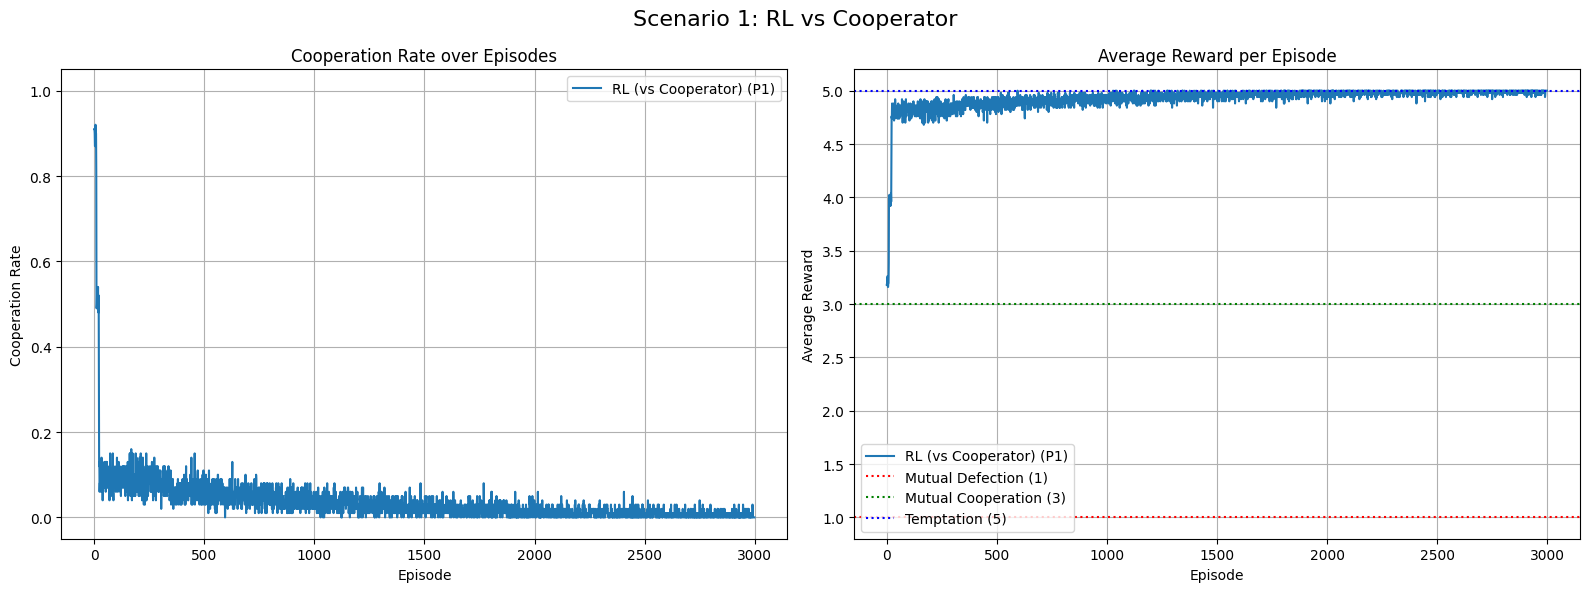

--- Running Scenario 2: RL vs Defector ---


Sim: RL (vs Defector) vs Defector:   0%|          | 0/3000 [00:00<?, ?it/s]

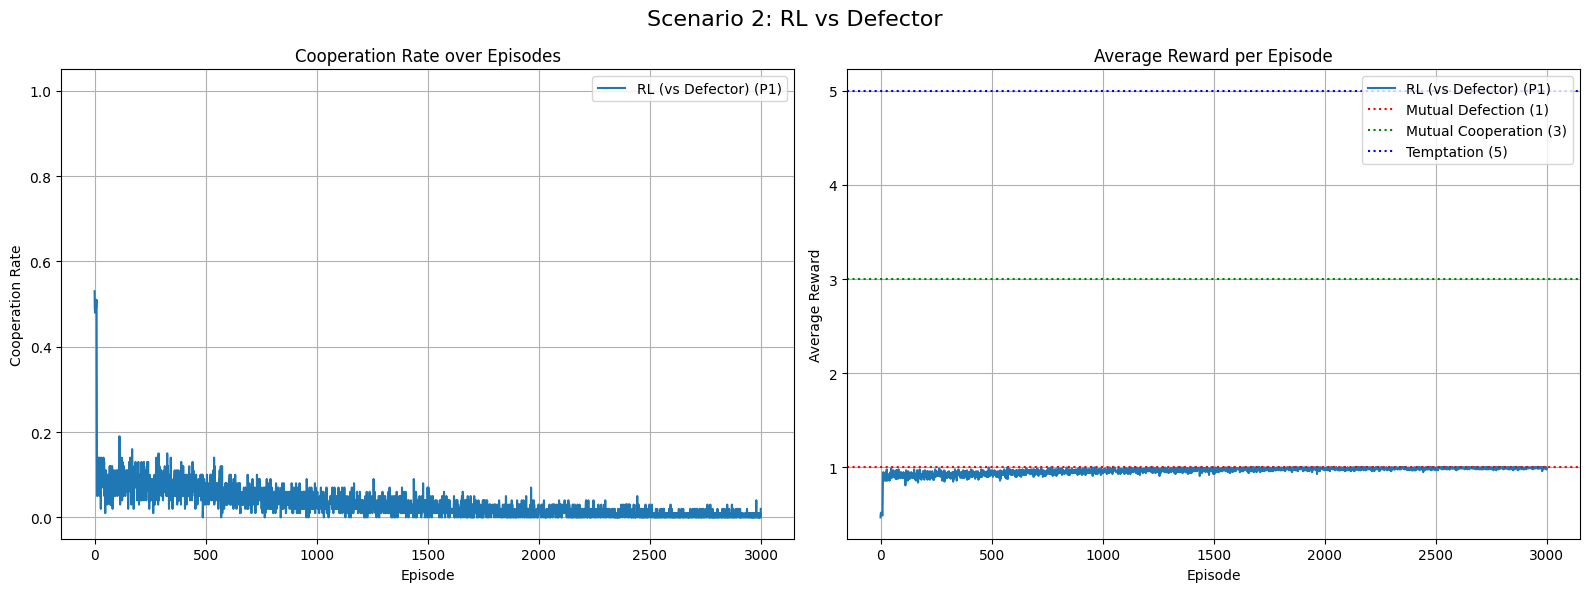


--- Running Scenario 3: RL vs Tit4Tat ---


Sim: RL (vs Tit4Tat) vs Tit4Tat:   0%|          | 0/3000 [00:00<?, ?it/s]

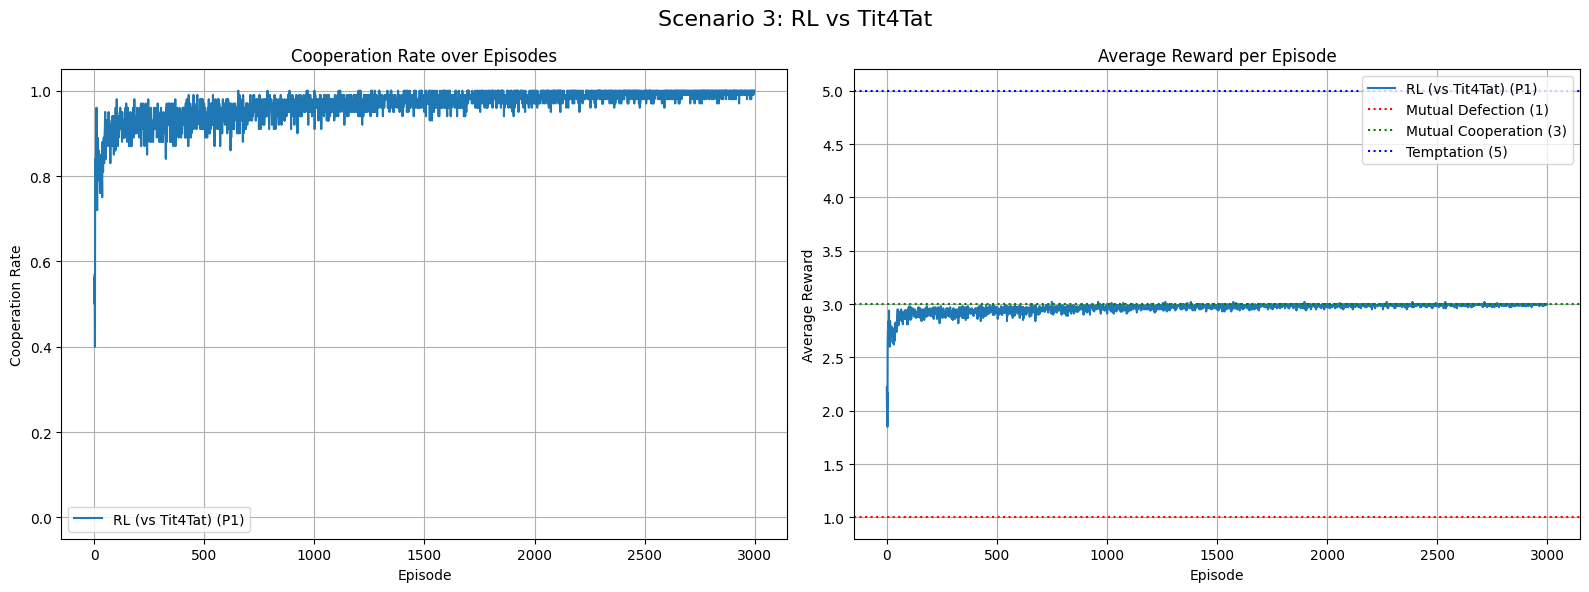


--- Running Scenario 4: RL vs Resentful ---


Sim: RL (vs Resentful, g=0.95) vs Resentful:   0%|          | 0/3000 [00:00<?, ?it/s]

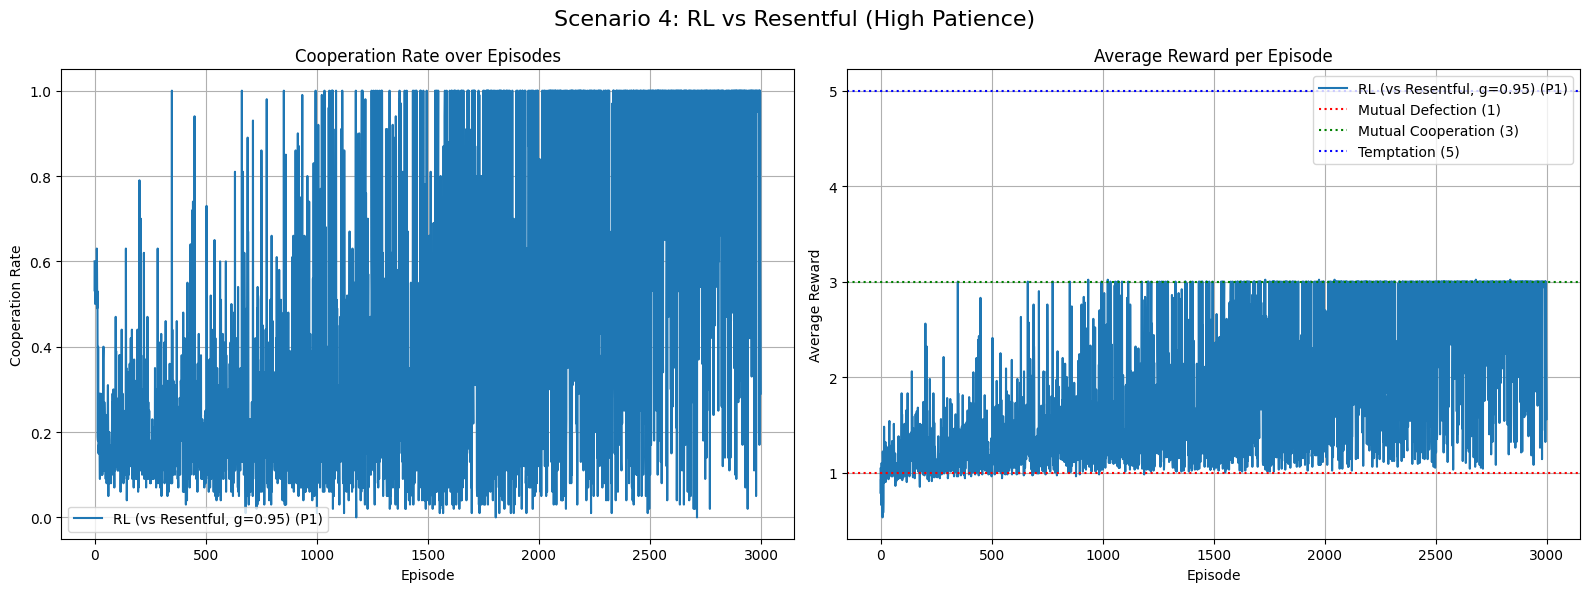


--- Running Scenario 5: RL vs Tit42Tat ---


Sim: RL (vs Tit42Tat) vs Tit42Tat:   0%|          | 0/3000 [00:00<?, ?it/s]

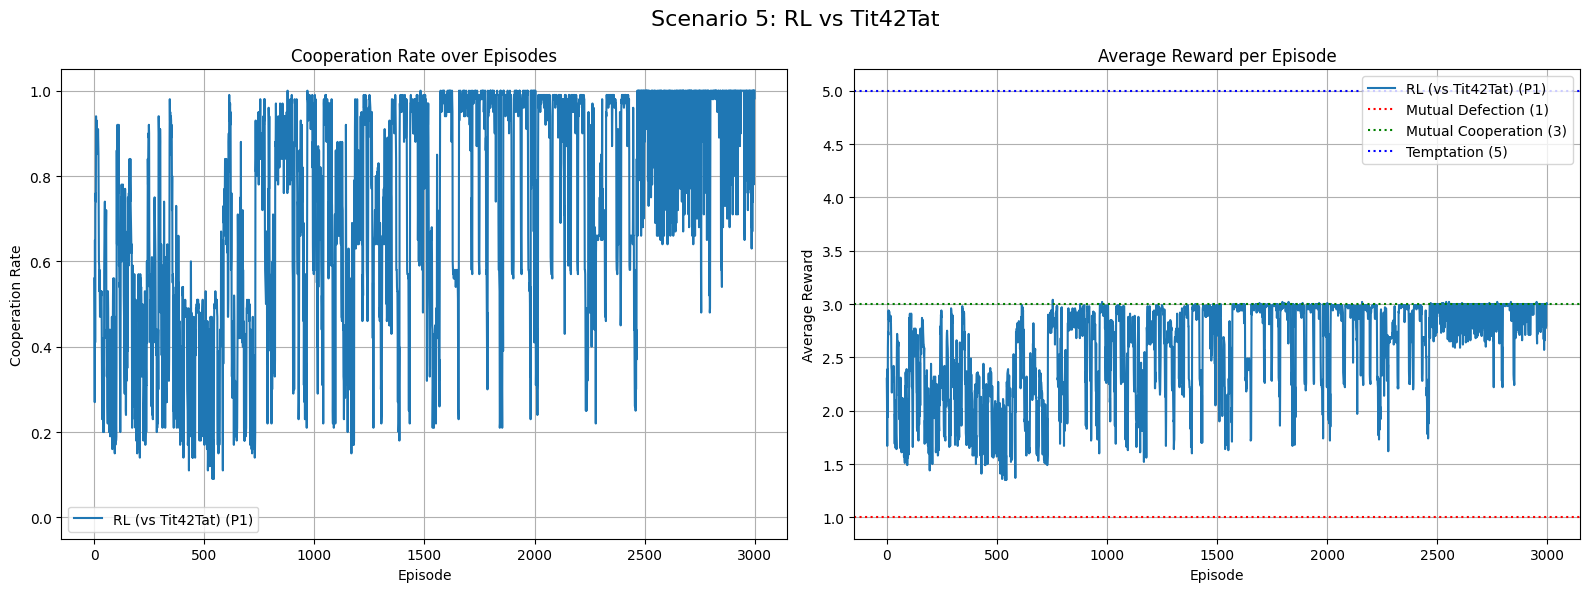


--- Running Scenario 6: RL vs Tester ---


Sim: RL (vs Tester) vs Tester:   0%|          | 0/3000 [00:00<?, ?it/s]

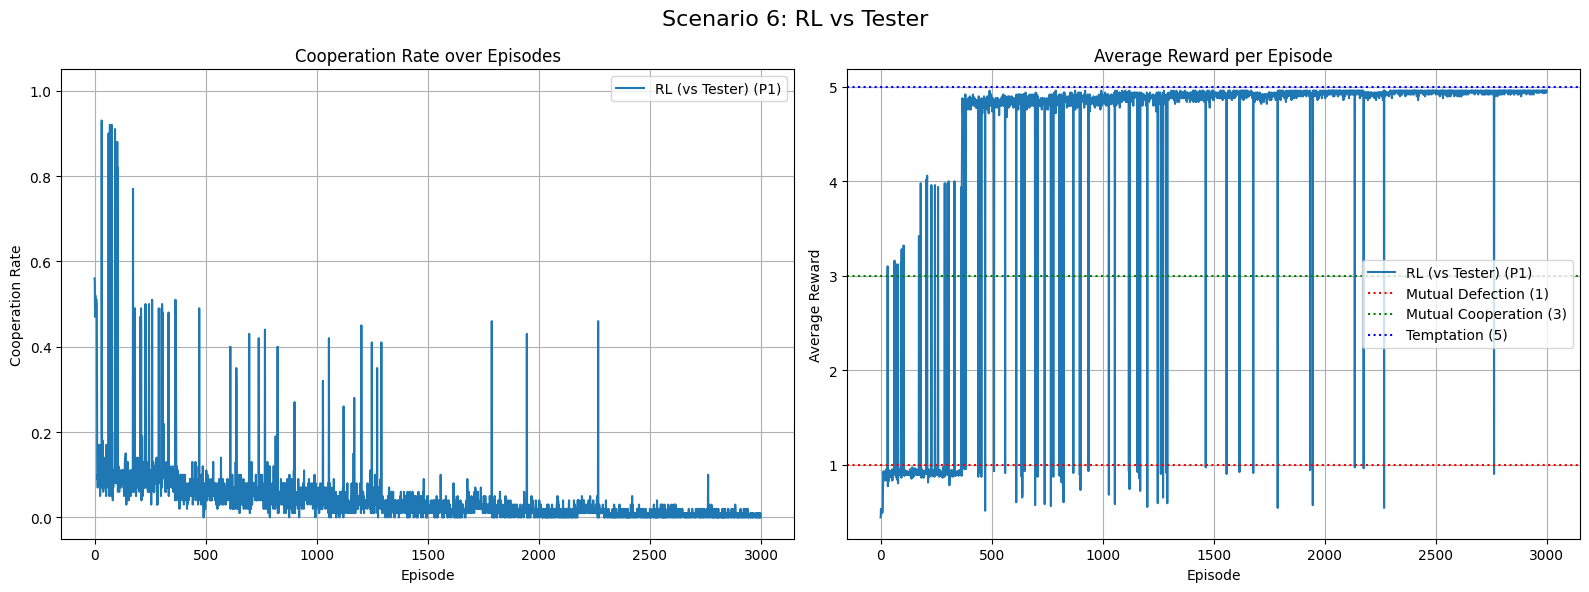


--- Running Scenario 7: RL vs Majority ---


Sim: RL (vs Majority) vs Majority:   0%|          | 0/3000 [00:00<?, ?it/s]

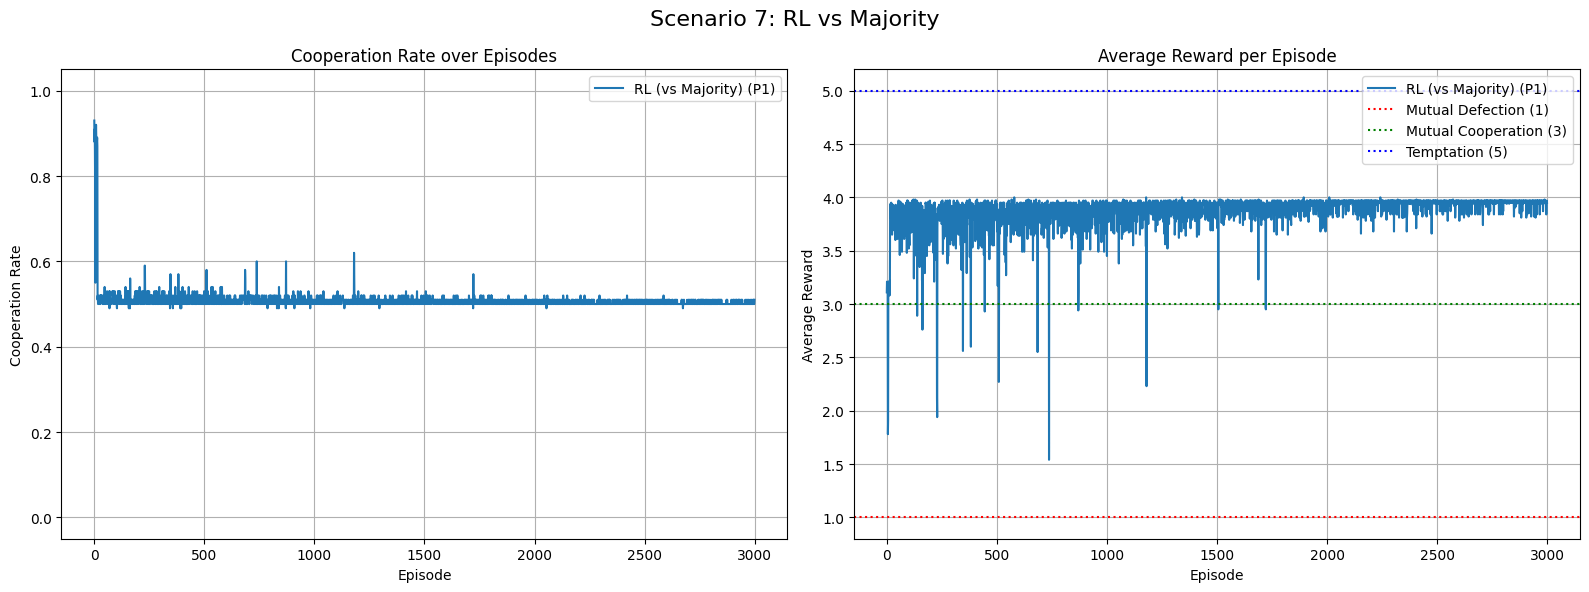


--- Running Scenario 8: RL vs RandomAgent ---


Sim: RL (vs Random) vs RandomAgent:   0%|          | 0/3000 [00:00<?, ?it/s]

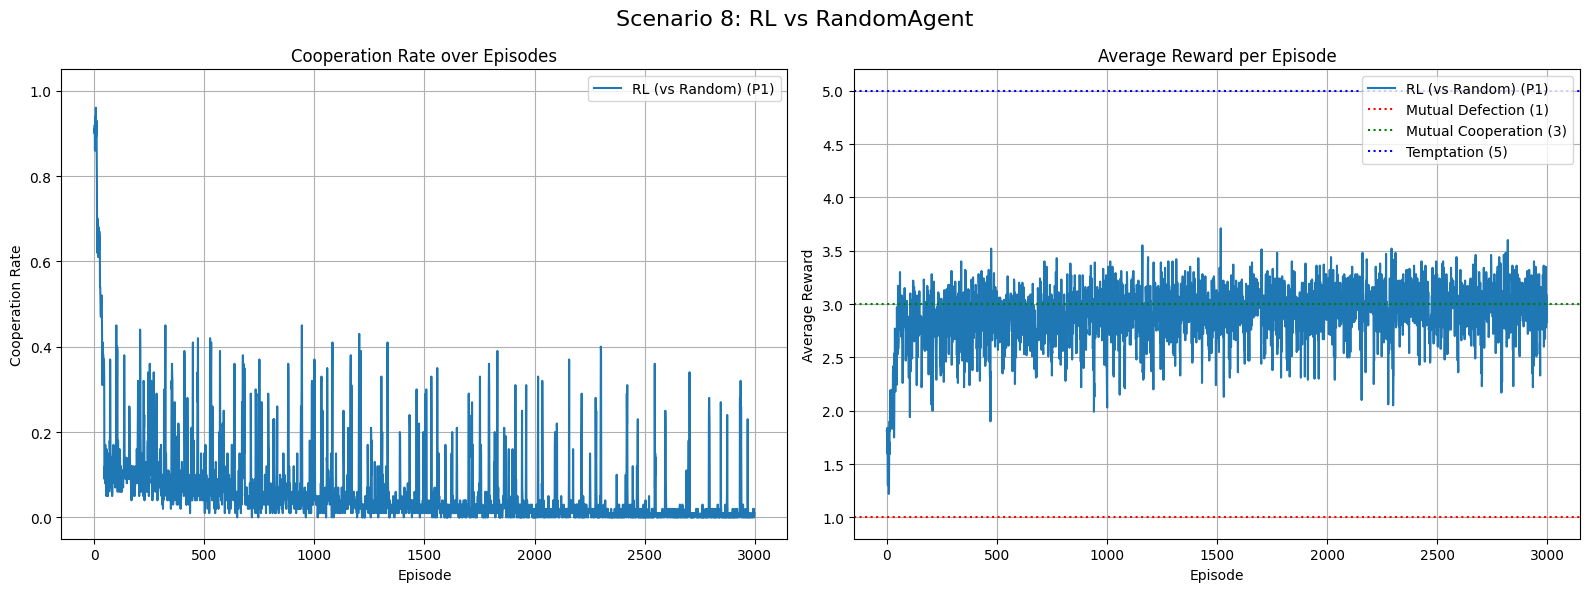


--- Running Scenario 9: RL vs RL ---


Sim: RL Agent 1 vs RL Agent 2:   0%|          | 0/3000 [00:00<?, ?it/s]

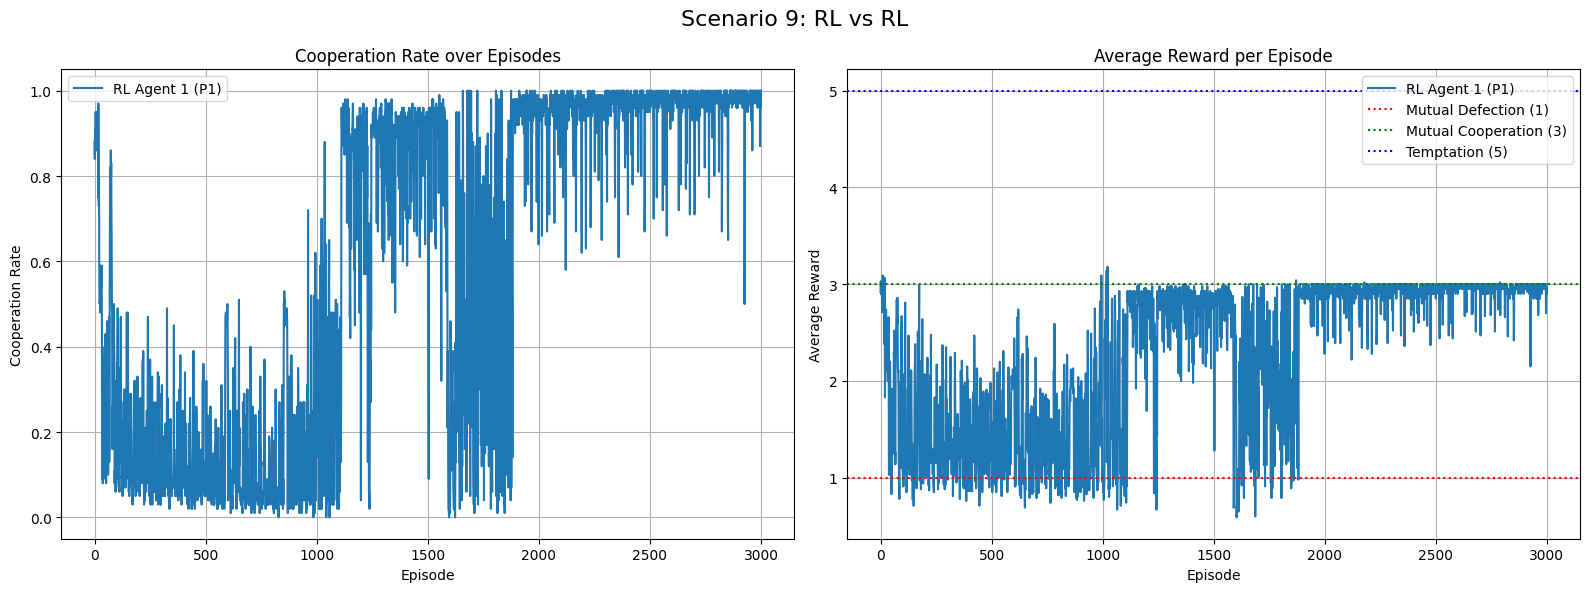


--- All 9 Q-Learning experiments complete! ---


In [ ]:
print("\n\n--- Starting Q-Learning vs. All Strategies Experiments ---")

# --- Global Hyperparameters ---
NUM_EPISODES = 3000   # As suggested, 3k-10k
EPISODE_LENGTH = 100  # As suggested

# We store the final trained agents and their Q-tables for analysis
trained_agents = {}
final_histories = {}

# --- Scenario 1: RL vs Cooperator ---
print("\n--- Running Scenario 1: RL vs Cooperator ---")
rl_agent_1 = QLearningAgent(name="RL (vs Cooperator)")
ac_agent = Cooperator()
h1, h2, trained_agents['rl_vs_ac'], _ = run_simulation(
    rl_agent_1, ac_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
final_histories['rl_vs_ac'] = (h1, h2)
plot_results(h1, h2, rl_agent_1.name, ac_agent.name, "Scenario 1: RL vs Cooperator")


# --- Scenario 2: RL vs Defector ---
print("--- Running Scenario 2: RL vs Defector ---")
rl_agent_2 = QLearningAgent(name="RL (vs Defector)")
ad_agent = Defector()
h1, h2, trained_agents['rl_vs_ad'], _ = run_simulation(
    rl_agent_2, ad_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
final_histories['rl_vs_ad'] = (h1, h2)
plot_results(h1, h2, rl_agent_2.name, ad_agent.name, "Scenario 2: RL vs Defector")


# --- Scenario 3: RL vs Tit4Tat ---
print("\n--- Running Scenario 3: RL vs Tit4Tat ---")
rl_agent_3 = QLearningAgent(name="RL (vs Tit4Tat)")
tft_agent = Tit4Tat()
h1, h2, trained_agents['rl_vs_tft'], _ = run_simulation(
    rl_agent_3, tft_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
final_histories['rl_vs_tft'] = (h1, h2)
plot_results(h1, h2, rl_agent_3.name, tft_agent.name, "Scenario 3: RL vs Tit4Tat")


# --- Scenario 4: RL vs Resentful (Grim Trigger) ---
print("\n--- Running Scenario 4: RL vs Resentful ---")
rl_agent_4 = QLearningAgent(name="RL (vs Resentful, g=0.95)", discount_factor=0.95)
gt_agent = Resentful()
h1, h2, trained_agents['rl_vs_gt'], _ = run_simulation(
    rl_agent_4, gt_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
final_histories['rl_vs_gt'] = (h1, h2)
plot_results(h1, h2, rl_agent_4.name, gt_agent.name, "Scenario 4: RL vs Resentful (High Patience)")


# --- Scenario 5: RL vs Tit42Tat ---
print("\n--- Running Scenario 5: RL vs Tit42Tat ---")
rl_agent_5 = QLearningAgent(name="RL (vs Tit42Tat)")
t42t_agent = Tit42Tat()
h1, h2, trained_agents['rl_vs_t42t'], _ = run_simulation(
    rl_agent_5, t42t_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
final_histories['rl_vs_t42t'] = (h1, h2)
plot_results(h1, h2, rl_agent_5.name, t42t_agent.name, "Scenario 5: RL vs Tit42Tat")


# --- Scenario 6: RL vs Tester ---
print("\n--- Running Scenario 6: RL vs Tester ---")
rl_agent_6 = QLearningAgent(name="RL (vs Tester)")
tester_agent = Tester()
h1, h2, trained_agents['rl_vs_tester'], _ = run_simulation(
    rl_agent_6, tester_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
final_histories['rl_vs_tester'] = (h1, h2)
plot_results(h1, h2, rl_agent_6.name, tester_agent.name, "Scenario 6: RL vs Tester")


# --- Scenario 7: RL vs Majority ---
print("\n--- Running Scenario 7: RL vs Majority ---")
rl_agent_7 = QLearningAgent(name="RL (vs Majority)")
majority_agent = Majority()
h1, h2, trained_agents['rl_vs_majority'], _ = run_simulation(
    rl_agent_7, majority_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
final_histories['rl_vs_majority'] = (h1, h2)
plot_results(h1, h2, rl_agent_7.name, majority_agent.name, "Scenario 7: RL vs Majority")


# --- Scenario 8: RL vs RandomAgent ---
print("\n--- Running Scenario 8: RL vs RandomAgent ---")
rl_agent_8 = QLearningAgent(name="RL (vs Random)")
random_agent = RandomAgent()
h1, h2, trained_agents['rl_vs_random'], _ = run_simulation(
    rl_agent_8, random_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
final_histories['rl_vs_random'] = (h1, h2)
plot_results(h1, h2, rl_agent_8.name, random_agent.name, "Scenario 8: RL vs RandomAgent")


# --- Scenario 9: RL vs RL ---
print("\n--- Running Scenario 9: RL vs RL ---")
rl_agent_9a = QLearningAgent(name="RL Agent 1")
rl_agent_9b = QLearningAgent(name="RL Agent 2")
h1, h2, trained_agents['rl_vs_rl_A'], trained_agents['rl_vs_rl_B'] = run_simulation(
    rl_agent_9a, rl_agent_9b, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
final_histories['rl_vs_rl'] = (h1, h2)
plot_results(h1, h2, rl_agent_9a.name, rl_agent_9b.name, "Scenario 9: RL vs RL")


print("\n--- All 9 Q-Learning experiments complete! ---")

#RL Q-Table Analysis


In [ ]:
print("--- Final Q-Tables for RL Agents ---")

# Define state and action labels for readability
state_labels = {0: "Start", 1: "(C,C)", 2: "(C,D)", 3: "(D,C)", 4: "(D,D)"}
action_labels = {0: "Cooperate", 1: "Defect"}

# Check if experiments have been run
if not trained_agents:
    print("RL experiments have not been run. Please run Section 6 first.")
else:
    for scenario_name, agent in trained_agents.items():
        if not isinstance(agent, QLearningAgent):
            continue

        print(f"\n--- {agent.name} (from {scenario_name}) ---")
        print("Q-Table:")
        print(f"State         | {action_labels[0]:<10} | {action_labels[1]:<10} | Best Action")
        print("-" * 55)

        for s in STATES:
            q_cooperate = agent.q_table[s, ACTION_COOPERATE]
            q_defect = agent.q_table[s, ACTION_DEFECT]

            best_action = action_labels[np.argmax(agent.q_table[s])]

            print(f"{state_labels[s]:<13} | {q_cooperate:<10.2f} | {q_defect:<10.2f} | {best_action}")

    # --- Example Summary Table (Section 5.6) ---
    print("\n\n--- Summary Table (Final 100 Episodes of RL Training) ---")
    print(f"{'Scenario':<18} | {'Opponent':<15} | {'Final Coop % (RL)':<20} | {'Final Avg Reward (RL)':<20}")
    print("-" * 80)

    def get_final_metrics(history):
        # Average the last 100 episodes for stability
        coop = np.mean(history['coop_rate'][-100:])
        reward = np.mean(history['avg_reward'][-100:])
        return f"{coop*100:.1f}%", f"{reward:.2f}"

    # --- UPDATED SUMMARY DICTIONARY ---
    # This now includes all 9 scenarios in the correct order
    scenarios_summary = {
        "RL vs Cooperator": ("Cooperator", final_histories['rl_vs_ac'][0]),
        "RL vs Defector": ("Defector", final_histories['rl_vs_ad'][0]),
        "RL vs Tit4Tat": ("Tit4Tat", final_histories['rl_vs_tft'][0]),
        "RL vs Resentful": ("Resentful", final_histories['rl_vs_gt'][0]),
        "RL vs Tit42Tat": ("Tit42Tat", final_histories['rl_vs_t42t'][0]),
        "RL vs Tester": ("Tester", final_histories['rl_vs_tester'][0]),
        "RL vs Majority": ("Majority", final_histories['rl_vs_majority'][0]),
        "RL vs RandomAgent": ("RandomAgent", final_histories['rl_vs_random'][0]),
        "RL vs RL": ("RL Agent", final_histories['rl_vs_rl'][0])
    }
    # --- END OF UPDATE ---

    for name, (opponent, h1) in scenarios_summary.items():
        coop_str, reward_str = get_final_metrics(h1)
        print(f"{name:<18} | {opponent:<15} | {coop_str:<20} | {reward_str:<20}")

--- Final Q-Tables for RL Agents ---

--- RL (vs Cooperator) (from rl_vs_ac) ---
Q-Table:
State         | Cooperate  | Defect     | Best Action
-------------------------------------------------------
Start         | 98.00      | 100.00     | Defect
(C,C)         | 98.00      | 100.00     | Defect
(C,D)         | 0.00       | 0.00       | Cooperate
(D,C)         | 98.00      | 100.00     | Defect
(D,D)         | 0.00       | 0.00       | Cooperate

--- RL (vs Defector) (from rl_vs_ad) ---
Q-Table:
State         | Cooperate  | Defect     | Best Action
-------------------------------------------------------
Start         | 19.00      | 20.00      | Defect
(C,C)         | 0.00       | 0.00       | Cooperate
(C,D)         | 19.00      | 20.00      | Defect
(D,C)         | 0.00       | 0.00       | Cooperate
(D,D)         | 19.00      | 20.00      | Defect

--- RL (vs Tit4Tat) (from rl_vs_tft) ---
Q-Table:
State         | Cooperate  | Defect     | Best Action
--------------------------------

#SARSA vs. Fixed Strategy Experiments



--- Starting SARSA vs. All Strategies Experiments ---

--- Running Scenario 1: SARSA vs Cooperator ---


Sim: SARSA (vs Cooperator) vs Cooperator:   0%|          | 0/3000 [00:00<?, ?it/s]

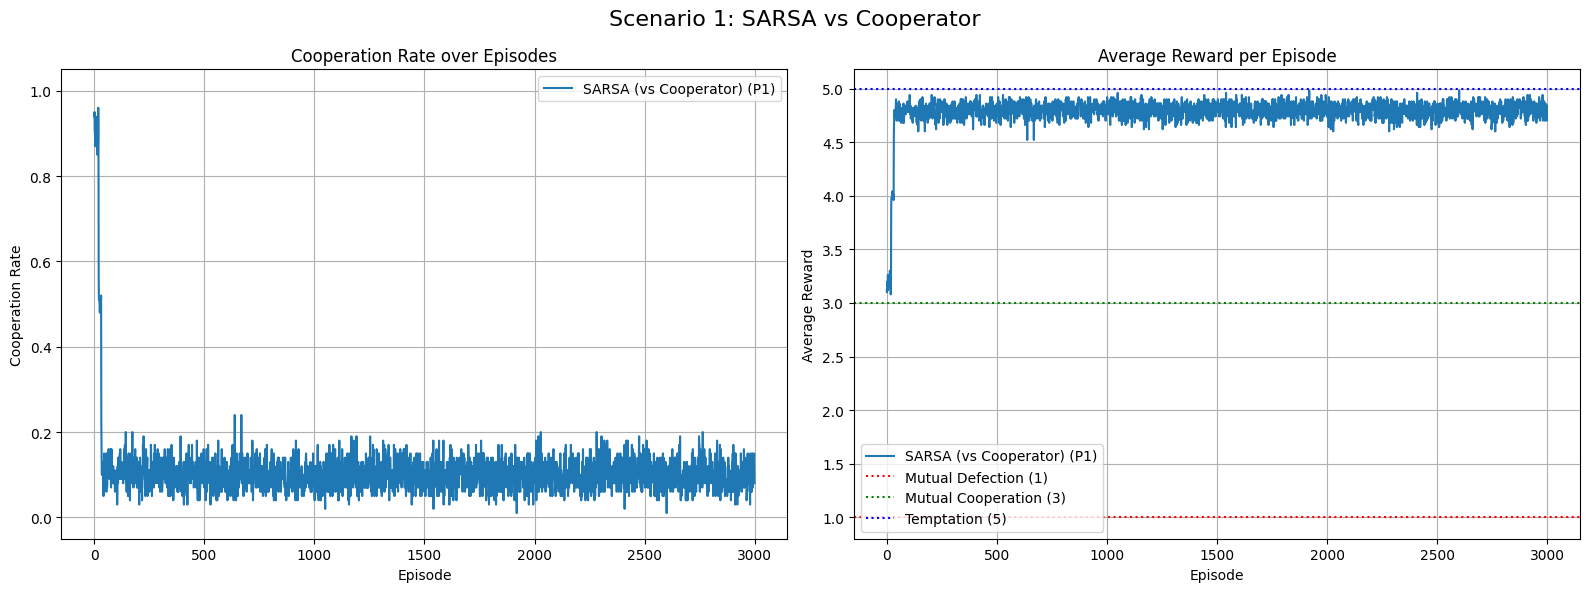

--- Running Scenario 2: SARSA vs Defector ---


Sim: SARSA (vs Defector) vs Defector:   0%|          | 0/3000 [00:00<?, ?it/s]

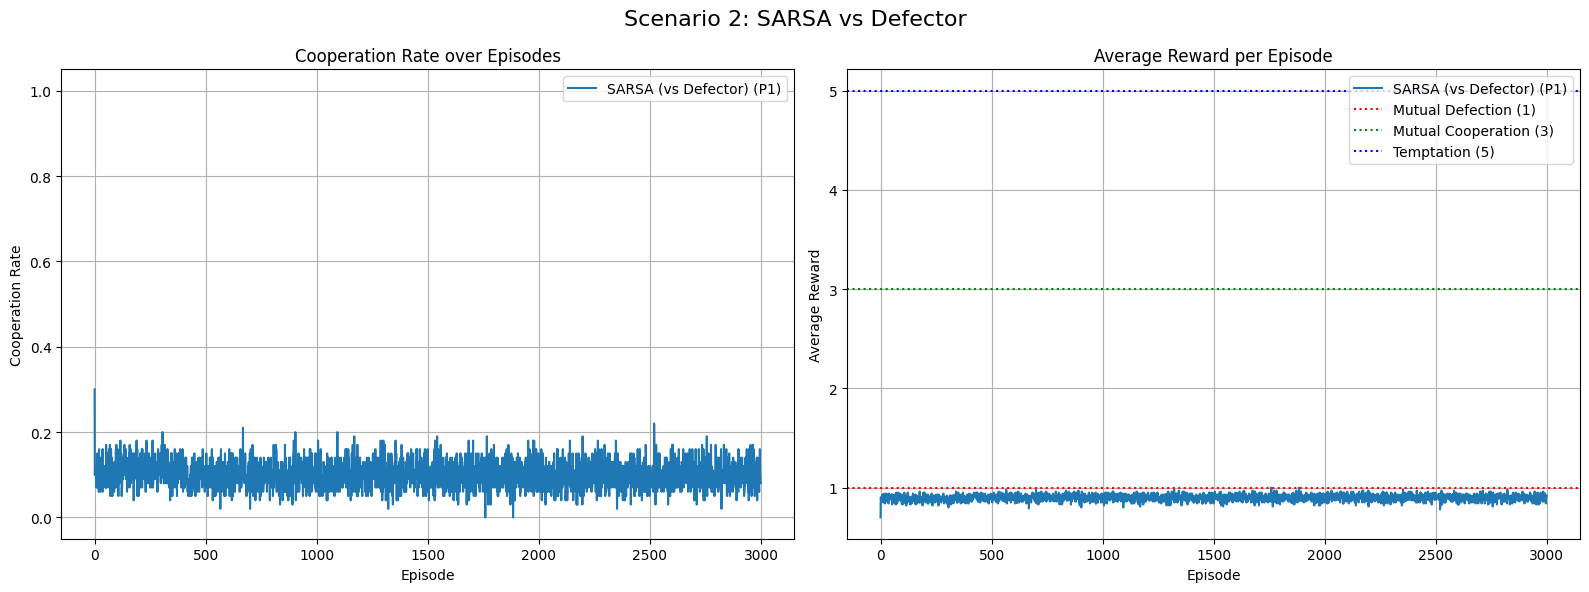


--- Running Scenario 3: SARSA vs Tit4Tat ---


Sim: SARSA (vs Tit4Tat) vs Tit4Tat:   0%|          | 0/3000 [00:00<?, ?it/s]

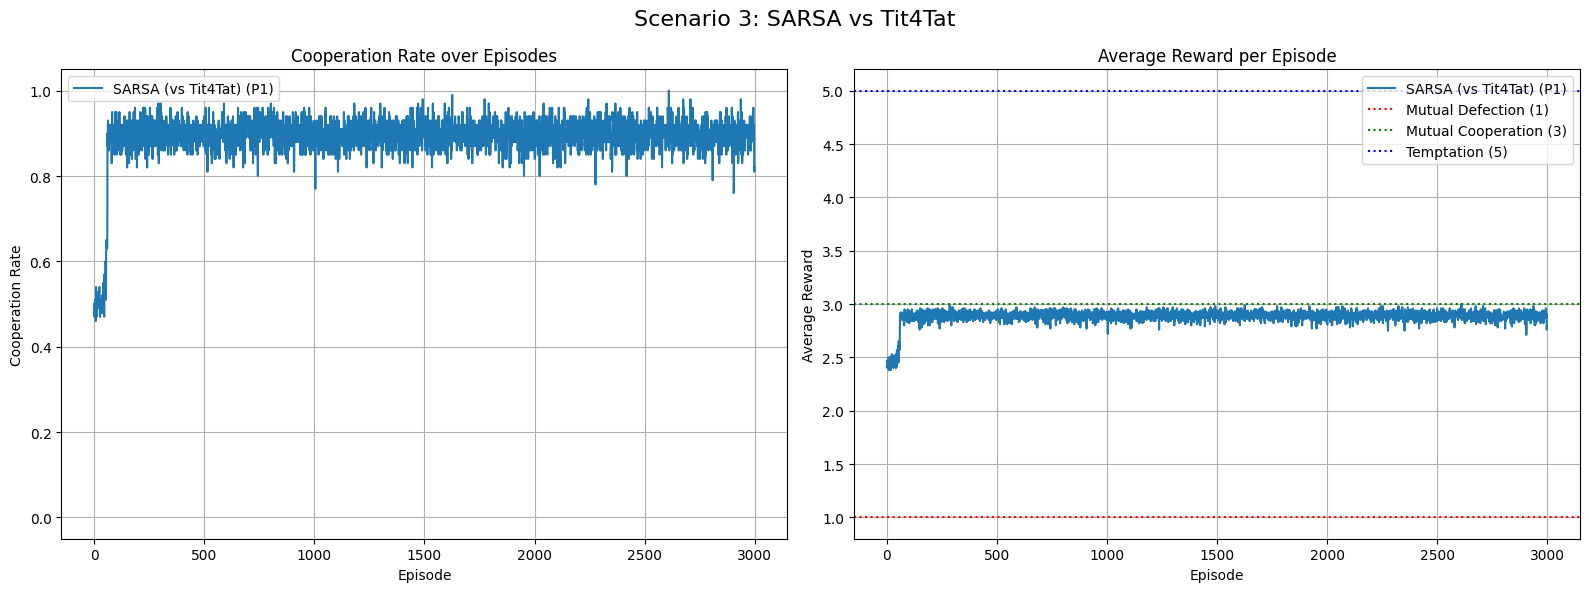


--- Running Scenario 4: SARSA vs Resentful ---


Sim: SARSA (vs Resentful, g=0.95) vs Resentful:   0%|          | 0/3000 [00:00<?, ?it/s]

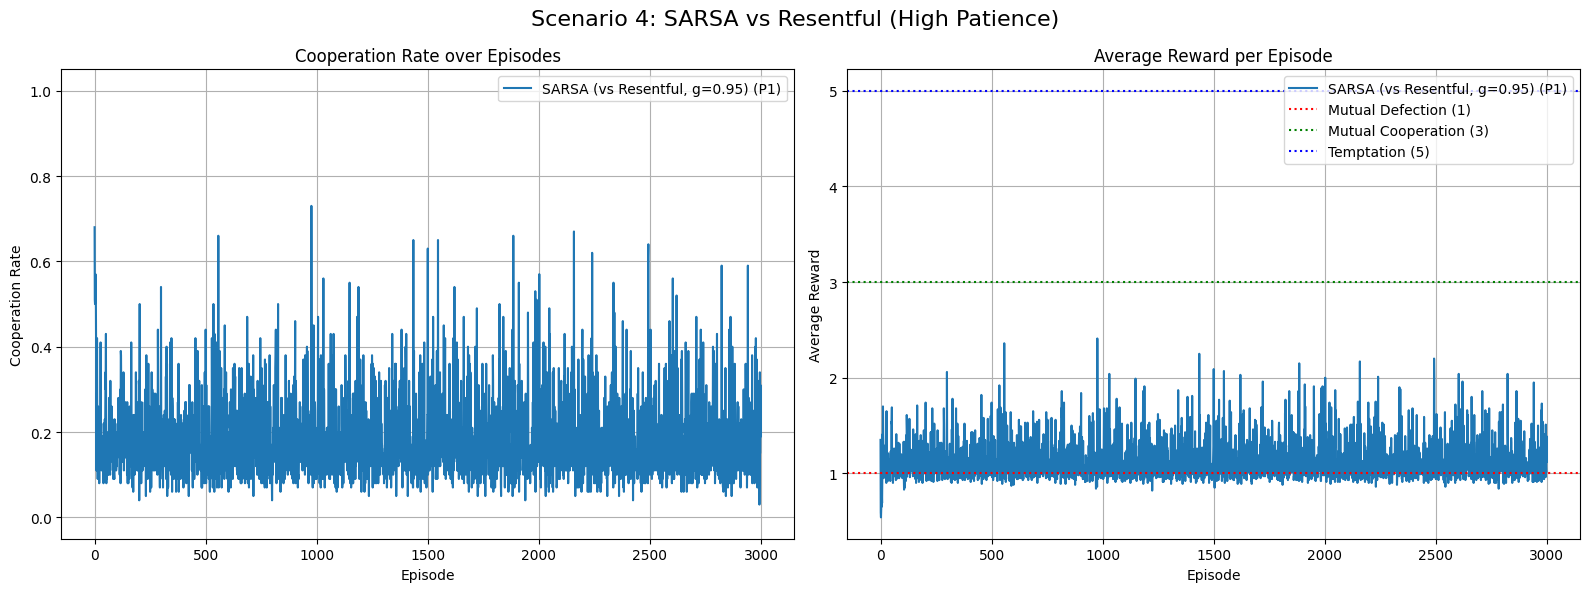


--- Running Scenario 5: SARSA vs Tit42Tat ---


Sim: SARSA (vs Tit42Tat) vs Tit42Tat:   0%|          | 0/3000 [00:00<?, ?it/s]

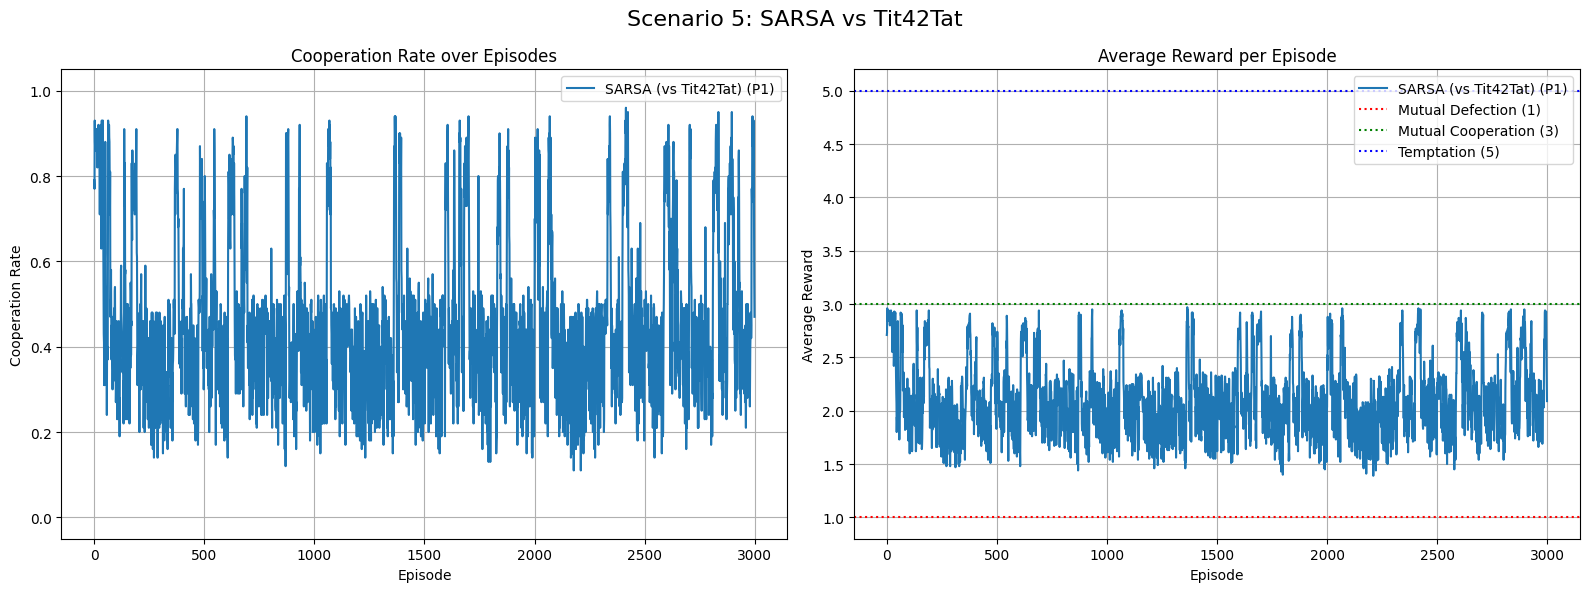


--- Running Scenario 6: SARSA vs Tester ---


Sim: SARSA (vs Tester) vs Tester:   0%|          | 0/3000 [00:00<?, ?it/s]

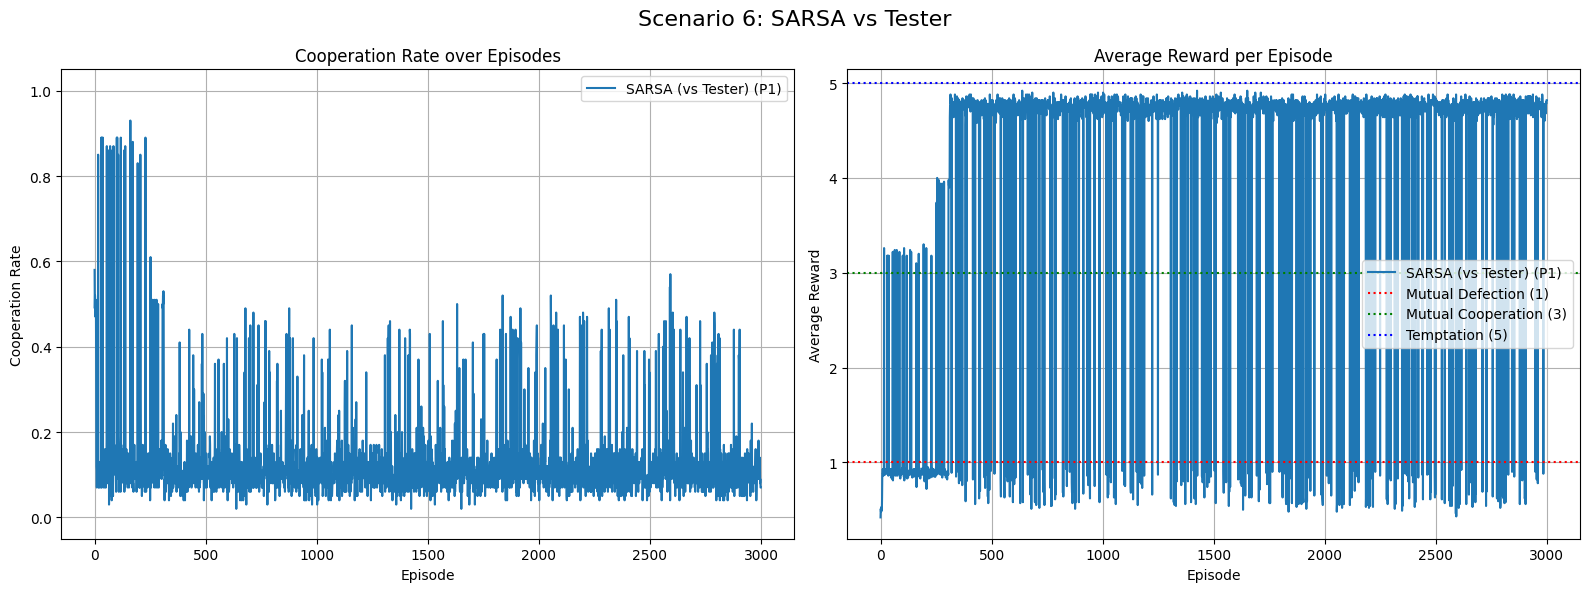


--- Running Scenario 7: SARSA vs Majority ---


Sim: SARSA (vs Majority) vs Majority:   0%|          | 0/3000 [00:00<?, ?it/s]

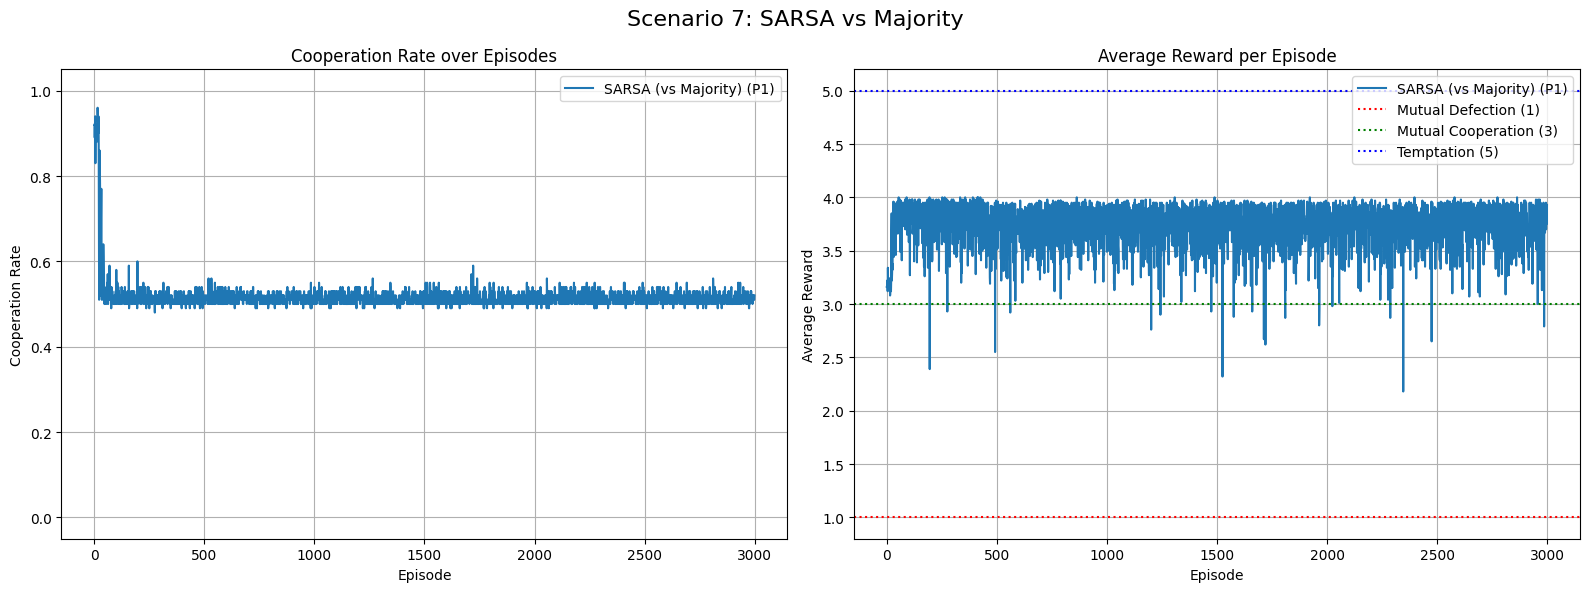


--- Running Scenario 8: SARSA vs RandomAgent ---


Sim: SARSA (vs Random) vs RandomAgent:   0%|          | 0/3000 [00:00<?, ?it/s]

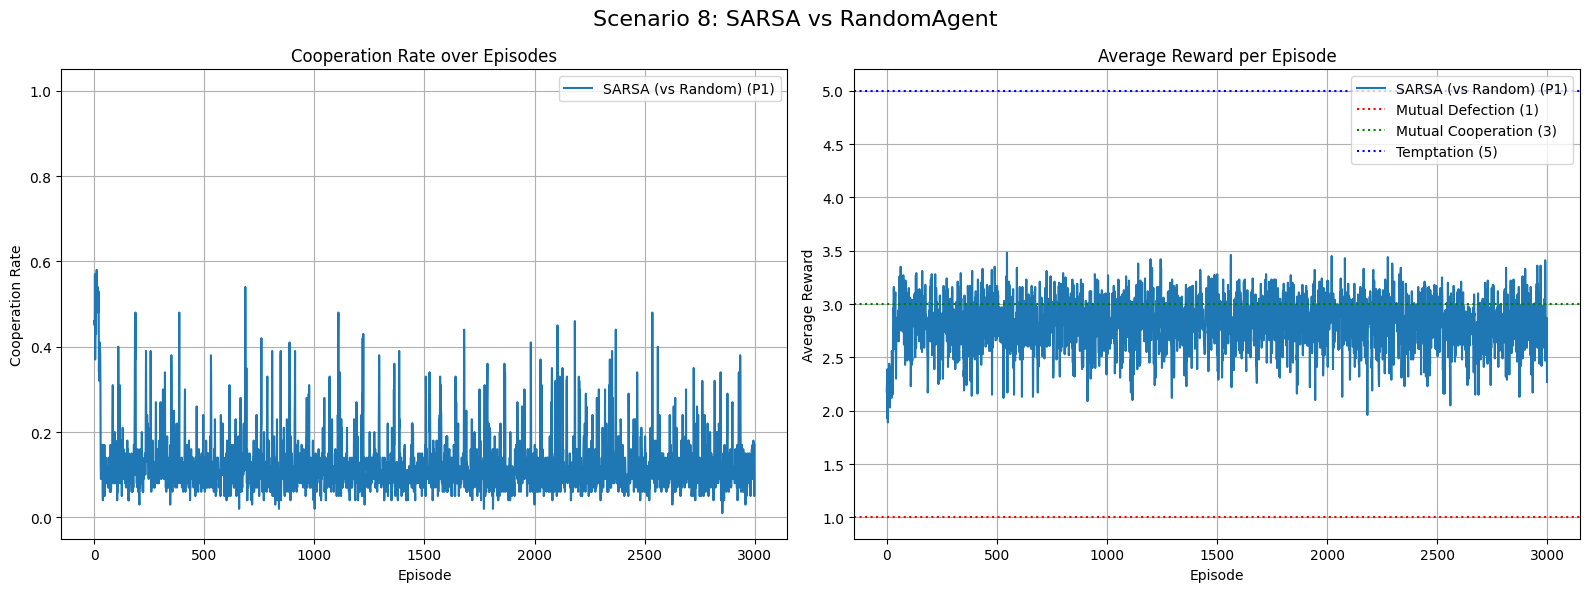


--- Running Scenario 9: SARSA vs SARSA ---


Sim: SARSA Agent 1 vs SARSA Agent 2:   0%|          | 0/3000 [00:00<?, ?it/s]

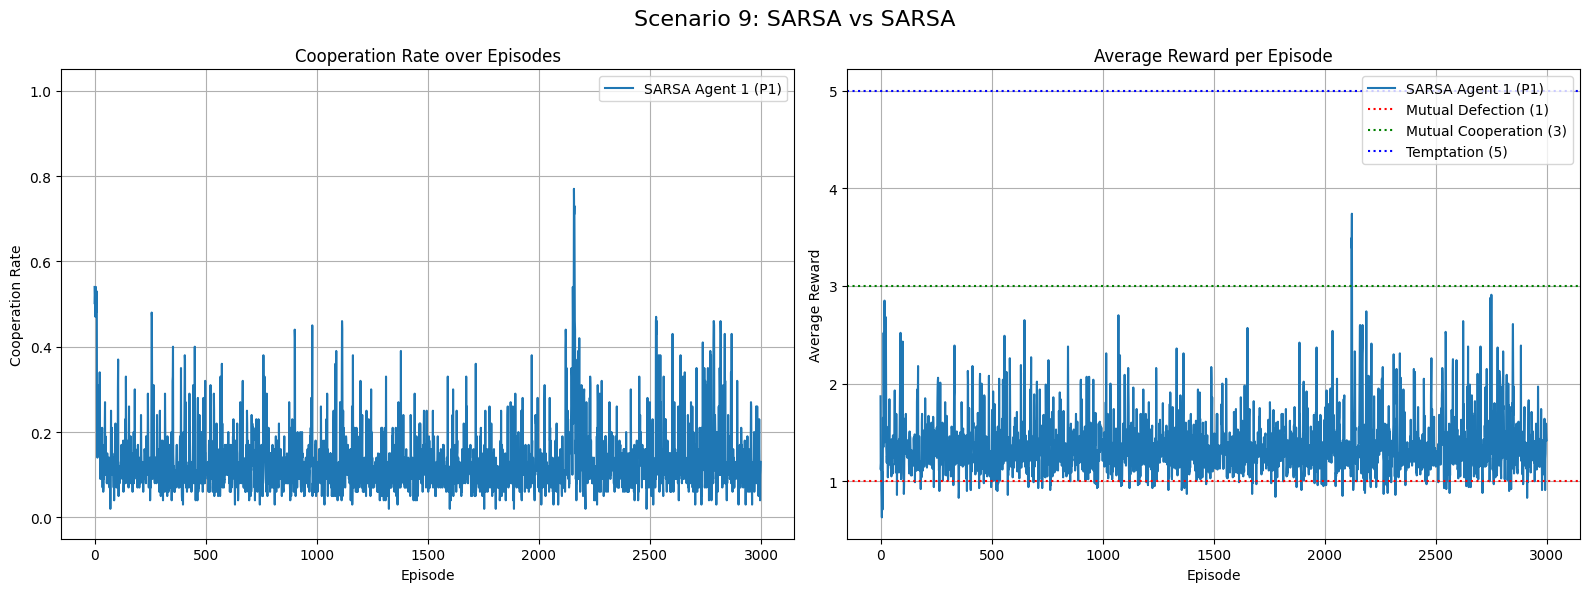


--- All 9 SARSA experiments complete! ---


In [ ]:
print("\n\n--- Starting SARSA vs. All Strategies Experiments ---")

# --- Global Hyperparameters (Kept the same for fair comparison) ---
NUM_EPISODES = 3000
EPISODE_LENGTH = 100

# We'll store these in separate dictionaries to compare with the Q-Learning results
sarsa_trained_agents = {}
sarsa_final_histories = {}

# --- Scenario 1: SARSA vs Cooperator ---
print("\n--- Running Scenario 1: SARSA vs Cooperator ---")
sarsa_agent_1 = SARSAAgent(name="SARSA (vs Cooperator)")
ac_agent = Cooperator()
h1, h2, sarsa_trained_agents['sarsa_vs_ac'], _ = run_simulation(
    sarsa_agent_1, ac_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
sarsa_final_histories['sarsa_vs_ac'] = (h1, h2)
plot_results(h1, h2, sarsa_agent_1.name, ac_agent.name, "Scenario 1: SARSA vs Cooperator")


# --- Scenario 2: SARSA vs Defector ---
print("--- Running Scenario 2: SARSA vs Defector ---")
sarsa_agent_2 = SARSAAgent(name="SARSA (vs Defector)")
ad_agent = Defector()
h1, h2, sarsa_trained_agents['sarsa_vs_ad'], _ = run_simulation(
    sarsa_agent_2, ad_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
sarsa_final_histories['sarsa_vs_ad'] = (h1, h2)
plot_results(h1, h2, sarsa_agent_2.name, ad_agent.name, "Scenario 2: SARSA vs Defector")


# --- Scenario 3: SARSA vs Tit4Tat ---
print("\n--- Running Scenario 3: SARSA vs Tit4Tat ---")
sarsa_agent_3 = SARSAAgent(name="SARSA (vs Tit4Tat)")
tft_agent = Tit4Tat()
h1, h2, sarsa_trained_agents['sarsa_vs_tft'], _ = run_simulation(
    sarsa_agent_3, tft_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
sarsa_final_histories['sarsa_vs_tft'] = (h1, h2)
plot_results(h1, h2, sarsa_agent_3.name, tft_agent.name, "Scenario 3: SARSA vs Tit4Tat")


# --- Scenario 4: SARSA vs Resentful (Grim Trigger) ---
print("\n--- Running Scenario 4: SARSA vs Resentful ---")
sarsa_agent_4 = SARSAAgent(name="SARSA (vs Resentful, g=0.95)", discount_factor=0.95)
gt_agent = Resentful()
h1, h2, sarsa_trained_agents['sarsa_vs_gt'], _ = run_simulation(
    sarsa_agent_4, gt_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
sarsa_final_histories['sarsa_vs_gt'] = (h1, h2)
plot_results(h1, h2, sarsa_agent_4.name, gt_agent.name, "Scenario 4: SARSA vs Resentful (High Patience)")


# --- Scenario 5: SARSA vs Tit42Tat ---
print("\n--- Running Scenario 5: SARSA vs Tit42Tat ---")
sarsa_agent_5 = SARSAAgent(name="SARSA (vs Tit42Tat)")
t42t_agent = Tit42Tat()
h1, h2, sarsa_trained_agents['sarsa_vs_t42t'], _ = run_simulation(
    sarsa_agent_5, t42t_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
sarsa_final_histories['sarsa_vs_t42t'] = (h1, h2)
plot_results(h1, h2, sarsa_agent_5.name, t42t_agent.name, "Scenario 5: SARSA vs Tit42Tat")


# --- Scenario 6: SARSA vs Tester ---
print("\n--- Running Scenario 6: SARSA vs Tester ---")
sarsa_agent_6 = SARSAAgent(name="SARSA (vs Tester)")
tester_agent = Tester()
h1, h2, sarsa_trained_agents['sarsa_vs_tester'], _ = run_simulation(
    sarsa_agent_6, tester_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
sarsa_final_histories['sarsa_vs_tester'] = (h1, h2)
plot_results(h1, h2, sarsa_agent_6.name, tester_agent.name, "Scenario 6: SARSA vs Tester")


# --- Scenario 7: SARSA vs Majority ---
print("\n--- Running Scenario 7: SARSA vs Majority ---")
sarsa_agent_7 = SARSAAgent(name="SARSA (vs Majority)")
majority_agent = Majority()
h1, h2, sarsa_trained_agents['sarsa_vs_majority'], _ = run_simulation(
    sarsa_agent_7, majority_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
sarsa_final_histories['sarsa_vs_majority'] = (h1, h2)
plot_results(h1, h2, sarsa_agent_7.name, majority_agent.name, "Scenario 7: SARSA vs Majority")


# --- Scenario 8: SARSA vs RandomAgent ---
print("\n--- Running Scenario 8: SARSA vs RandomAgent ---")
sarsa_agent_8 = SARSAAgent(name="SARSA (vs Random)")
random_agent = RandomAgent()
h1, h2, sarsa_trained_agents['sarsa_vs_random'], _ = run_simulation(
    sarsa_agent_8, random_agent, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
sarsa_final_histories['sarsa_vs_random'] = (h1, h2)
plot_results(h1, h2, sarsa_agent_8.name, random_agent.name, "Scenario 8: SARSA vs RandomAgent")


# --- Scenario 9: SARSA vs SARSA ---
print("\n--- Running Scenario 9: SARSA vs SARSA ---")
sarsa_agent_9a = SARSAAgent(name="SARSA Agent 1")
sarsa_agent_9b = SARSAAgent(name="SARSA Agent 2")
h1, h2, sarsa_trained_agents['sarsa_vs_sarsa_A'], sarsa_trained_agents['sarsa_vs_sarsa_B'] = run_simulation(
    sarsa_agent_9a, sarsa_agent_9b, NUM_EPISODES, EPISODE_LENGTH, show_progress=True
)
sarsa_final_histories['sarsa_vs_sarsa'] = (h1, h2)
plot_results(h1, h2, sarsa_agent_9a.name, sarsa_agent_9b.name, "Scenario 9: SARSA vs SARSA")


print("\n--- All 9 SARSA experiments complete! ---")

In [ ]:
print("--- Final Q-Tables for SARSA Agents ---")

# Define state and action labels for readability (same as before)
state_labels = {0: "Start", 1: "(C,C)", 2: "(C,D)", 3: "(D,C)", 4: "(D,D)"}
action_labels = {0: "Cooperate", 1: "Defect"}

# Check if the SARSA experiments have been run
if not sarsa_trained_agents:
    print("SARSA experiments have not been run. Please run the previous cell first.")
else:
    for scenario_name, agent in sarsa_trained_agents.items():
        # Check for the SARSAAgent class
        if not isinstance(agent, SARSAAgent):
            continue

        print(f"\n--- {agent.name} (from {scenario_name}) ---")
        print("Q-Table:")
        print(f"State         | {action_labels[0]:<10} | {action_labels[1]:<10} | Best Action")
        print("-" * 55)

        for s in STATES:
            q_cooperate = agent.q_table[s, ACTION_COOPERATE]
            q_defect = agent.q_table[s, ACTION_DEFECT]

            best_action = action_labels[np.argmax(agent.q_table[s])]

            print(f"{state_labels[s]:<13} | {q_cooperate:<10.2f} | {q_defect:<10.2f} | {best_action}")

    # --- Summary Table for SARSA Training ---
    print("\n\n--- Summary Table (Final 100 Episodes of SARSA Training) ---")
    print(f"{'Scenario':<20} | {'Opponent':<15} | {'Final Coop % (SARSA)':<20} | {'Final Avg Reward (SARSA)':<20}")
    print("-" * 85)

    # Helper function (no changes needed)
    def get_final_metrics(history):
        # Average the last 100 episodes for stability
        coop = np.mean(history['coop_rate'][-100:])
        reward = np.mean(history['avg_reward'][-100:])
        return f"{coop*100:.1f}%", f"{reward:.2f}"

    # --- UPDATED SUMMARY DICTIONARY ---
    # This now includes all 9 scenarios in the correct order
    sarsa_scenarios_summary = {
        "SARSA vs Cooperator": ("Cooperator", sarsa_final_histories['sarsa_vs_ac'][0]),
        "SARSA vs Defector": ("Defector", sarsa_final_histories['sarsa_vs_ad'][0]),
        "SARSA vs Tit4Tat": ("Tit4Tat", sarsa_final_histories['sarsa_vs_tft'][0]),
        "SARSA vs Resentful": ("Resentful", sarsa_final_histories['sarsa_vs_gt'][0]),
        "SARSA vs Tit42Tat": ("Tit42Tat", sarsa_final_histories['sarsa_vs_t42t'][0]),
        "SARSA vs Tester": ("Tester", sarsa_final_histories['sarsa_vs_tester'][0]),
        "SARSA vs Majority": ("Majority", sarsa_final_histories['sarsa_vs_majority'][0]),
        "SARSA vs RandomAgent": ("RandomAgent", sarsa_final_histories['sarsa_vs_random'][0]),
        "SARSA vs SARSA": ("SARSA Agent", sarsa_final_histories['sarsa_vs_sarsa'][0])
    }
    # --- END OF UPDATE ---

    # Loop and print the SARSA results
    for name, (opponent, h1) in sarsa_scenarios_summary.items():
        coop_str, reward_str = get_final_metrics(h1)
        print(f"{name:<20} | {opponent:<15} | {coop_str:<20} | {reward_str:<20}")

--- Final Q-Tables for SARSA Agents ---

--- SARSA (vs Cooperator) (from sarsa_vs_ac) ---
Q-Table:
State         | Cooperate  | Defect     | Best Action
-------------------------------------------------------
Start         | 93.83      | 96.00      | Defect
(C,C)         | 93.90      | 95.72      | Defect
(C,D)         | 0.00       | 0.00       | Cooperate
(D,C)         | 93.80      | 95.67      | Defect
(D,D)         | 0.00       | 0.00       | Cooperate

--- SARSA (vs Defector) (from sarsa_vs_ad) ---
Q-Table:
State         | Cooperate  | Defect     | Best Action
-------------------------------------------------------
Start         | 16.81      | 18.00      | Defect
(C,C)         | 0.00       | 0.00       | Cooperate
(C,D)         | 16.85      | 17.97      | Defect
(D,C)         | 0.00       | 0.00       | Cooperate
(D,D)         | 16.81      | 18.04      | Defect

--- SARSA (vs Tit4Tat) (from sarsa_vs_tft) ---
Q-Table:
State         | Cooperate  | Defect     | Best Action
-----------